In [1]:
import numpy as np
import string

In [19]:
def const_similarity(a, b, k=3):
    if a==b:
        return k
    else:
        return -k

In [17]:
def const_gap_penalty(k):
    return k

In [18]:
def linear_gap_penalty(k,W1=2):
    return k*W1

In [4]:
michelle = """
And Barack and I were raised with so many of the same values: that you work hard for what you want in life; that your word is your bond and you do what you say you're going to do; that you treat people with dignity and respect, even if you don't know them, and even if you don't agree with them.
And Barack and I set out to build lives guided by these values, and to pass them on to the next generation. Because we want our children - and all children in this nation - to know that the only limit to the height of your achievements is the reach of your dreams and your willingness to work for them.
"""

In [5]:
melania = """
From a young age, my parents impressed on me the values that you work hard for what you want in life, that your word is your bond and you do what you say and keep your promise, that you treat people with respect.
They taught and showed me values and morals in their daily lives. That is a lesson that I continue to pass along to our son. And we need to pass those lessons on to the many generations to follow. Because we want our children in this nation to know that the only limit to your achievements is the strength of your dreams and your willingness to work for them.
"""

In [6]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [7]:
m1 = michelle.translate(str.maketrans('','',string.punctuation)).strip().lower()

In [8]:
m2 = melania.translate(str.maketrans('','',string.punctuation)).strip().lower()

In [9]:
g1 = "G G T T G A C T A"
g2 = "T G T T A C G G"

In [10]:
import networkx as nx

In [72]:
class SemanticSmithWaterman(object):
    def __init__(self, gap_penalty='linear',
                       gap_penalty_const = 2,
                       similarity='const', 
                       sim_const=3):
        if gap_penalty not in ['linear','const']:
            if callable(gap_penalty):
                self.gp = gap_penalty
            else:
                raise Exception("gap_penalty must be callable, or one of {linear,const}")
        else:
            gp_disp_dict = {'linear':lambda k: linear_gap_penalty(k,gap_penalty_const),
                            'const': lambda k: const_gap_penalty(k)}
            self.gp = gp_disp_dict[gap_penalty]
        if similarity not in ['const']:
            if callable(similarity):
                self.s = similarity
            else:
                raise Exception("similarity must be callable or one of {const}")
        else:
            s_disp_dict = {'const':lambda a,b: const_similarity(a,b,k=sim_const)}
            self.s = s_disp_dict[similarity]
        
    def penalty_matrix_paths(self,s1,s2):
        G = nx.DiGraph()
        a = [None] + s1.split()
        b = [None] + s2.split()
        n = len(a) - 1
        m = len(b) - 1
        H = np.zeros((n+1, m+1))
        edges = []
        for i in range(1,n+1):
            for j in range(1,m+1):
                d = H[i-1,j-1] + s(a[i],b[j])
                u = np.max(H[0:i,j] - gap_penalty(np.arange(i,0,-1)))
                l = np.max(H[i,0:j] - gap_penalty(np.arange(j,0,-1)))
                #print(i,j,a[i],b[j],d,l,u)
                vals = np.array([d,l,u,0])
                H[i,j] = np.max(vals)
                u = (i,j)
                v = [(i-1,j-1),(i,j-1),(i-1,j),None][np.argmax(vals)]
                if v is not None:
                    G.add_edge(u,v)
        return H, G
    
    def ssw(self,s1,s2):
        H,G = self.penalty_matrix_paths(s1,s2)
        a = [None] + s1.split()
        b = [None] + s2.split()
        max_idxs = np.argwhere(H==np.max(H))
        paths = []
        print(max_idxs)
        for mi, mj in max_idxs:
            al_a = [a[mi]]
            al_b = [b[mj]]
            while G.out_degree((mi,mj)) > 0:
                prev = list(G.successors((mi,mj)))[0]
                ni = prev[0]
                nj = prev[1]
                if (ni != mi) and (nj != mj):
                    al_a.append(a[ni])
                    al_b.append(b[nj])
                elif (ni != mi) and (nj == mj):
                    al_a.append(a[ni])
                    al_b.append("-"*len(a[ni]))
                elif (ni == mi) and (nj != mj):
                    al_a.append("-"*len(b[nj]))
                    al_b.append(b[nj])
                mi = ni
                mj = nj
            al_a = list(reversed(al_a))
            al_b = list(reversed(al_b))
            al_str = " ".join(al_a) + "\n" + " ".join(al_b)
            paths.append((al_a,al_b,al_str))
        return paths

In [91]:
SSW = SemanticSmithWaterman(gap_penalty='const',gap_penalty_const=0.01,sim_const=10)

In [92]:
H,G = SSW.penalty_matrix_paths(m1,m2)

In [93]:
SSW.ssw(m1,m2)

[[119 112]]


[(['of',
   'the',
   'same',
   'values',
   'that',
   'you',
   'work',
   'hard',
   'for',
   'what',
   'you',
   'want',
   'in',
   'life',
   'that',
   'your',
   'word',
   'is',
   'your',
   'bond',
   'and',
   'you',
   'do',
   'what',
   'you',
   'say',
   'youre',
   'going',
   'to',
   'do',
   'that',
   'you',
   'treat',
   'people',
   'with',
   'dignity',
   'and',
   'respect',
   'even',
   'if',
   'you',
   'dont',
   'know',
   'them',
   'and',
   'even',
   'if',
   'you',
   'dont',
   'agree',
   'with',
   'them',
   'and',
   'barack',
   'and',
   'i',
   'set',
   'out',
   'to',
   'build',
   'lives',
   'guided',
   'by',
   'these',
   'values',
   '---',
   '--',
   'and',
   'to',
   '----',
   'pass',
   'them',
   'on',
   'to',
   '---',
   '----',
   'the',
   'next',
   'generation',
   'because',
   'we',
   'want',
   'our',
   'children',
   'and',
   'all',
   'children',
   'in',
   'this',
   'nation',
   'to',
   'know',
   'tha

In [71]:
np.argmax(H)

69

In [70]:
np.argwhere(H==np.max(H),)

array([[7, 6]])

In [12]:
H,G,al_a,al_b,al_str = ssw(m1,m2)

In [14]:
np.max(H)

82.0

In [15]:
for ridx in np.where(H==np.max(H)):
    

(array([119]), array([112]))

In [235]:
import matplotlib.pyplot as plt
%matplotlib inline

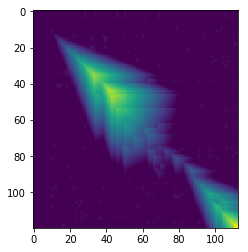

In [236]:
plt.imshow(H)